## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis
### Answer: The purpose of this analysis for Phase I is to find out if Line 3 is in statistical control based on the specifications.  Then setup a Phase II monitoring plan and analysis.
### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.
### Answer: The quality characteristic for this analysis is the diameter of the filament.  The filamter is measured in milameters (continous variable) and it is assumed to be normally distributed.
### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?
### Answer:  The $\bar{X}$ is appropriate because it captures the process mean and asks whether or not it is drifting.  The $R/s$ chart are appropriate because they measure the variability of the process.  All of these methods could signal an out of control process resulting in poorly manufactured filament.  The limitations are that it is assumed to be normally distributed and independent observations but in reality that many not be the case especially in a production environment.  Also, the process is only tracking one variable.  In this process if the laser is not appropriately callibrated it could cause issues. There is also a lot that can go wrong in the manufacturing process which can not be controlled by using a univariate control chart.  It would be relatively slow in detecting small gradual shifts.
## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.


In [ ]:
## Clone forked repository to Colab ##

## Specify your GitHub username:
user_name <- "Bishop13"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive for HW1:

setwd("STAT-7110-Quality-Control//Assignments//HW1")

In [ ]:
#install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Phase I Data ##

phase1 <- read_excel("FilamentDiameter_PhaseI.xlsx")
phase2 <- read_excel("FilamentDiameter_PhaseII.xlsx")

phase_1<- as.matrix(phase1[, c("Meas1","Meas2","Meas3","Meas4","Meas5")])

dim(phase1)
dim(phase2)

[1] 25  6

[1] 20  6

In [ ]:
xbar <- rowMeans(phase_1)
r    <- apply(phase_1, 1, max) - apply(phase_1, 1, min)
s    <- apply(phase_1, 1, sd)

mu_hat  <- mean(xbar)
sigma_R <- mean(r) / 2.326     # d2 for n = 5
sigma_S <- mean(s) / 0.9400    # c4 for n = 5
c(mu_hat, sigma_R, sigma_S)

[1] 1.75401739 0.01144864 0.01154467


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.
### Answer: No, the chart shows an out of control process at week 19.  If you look at the data, in week 19 there were two that were at 1.80 and two others that were close to 1.725.  That is a large fluctuation on one week.  This means that there was a problem in the process, be it a machine of measuring equipment.

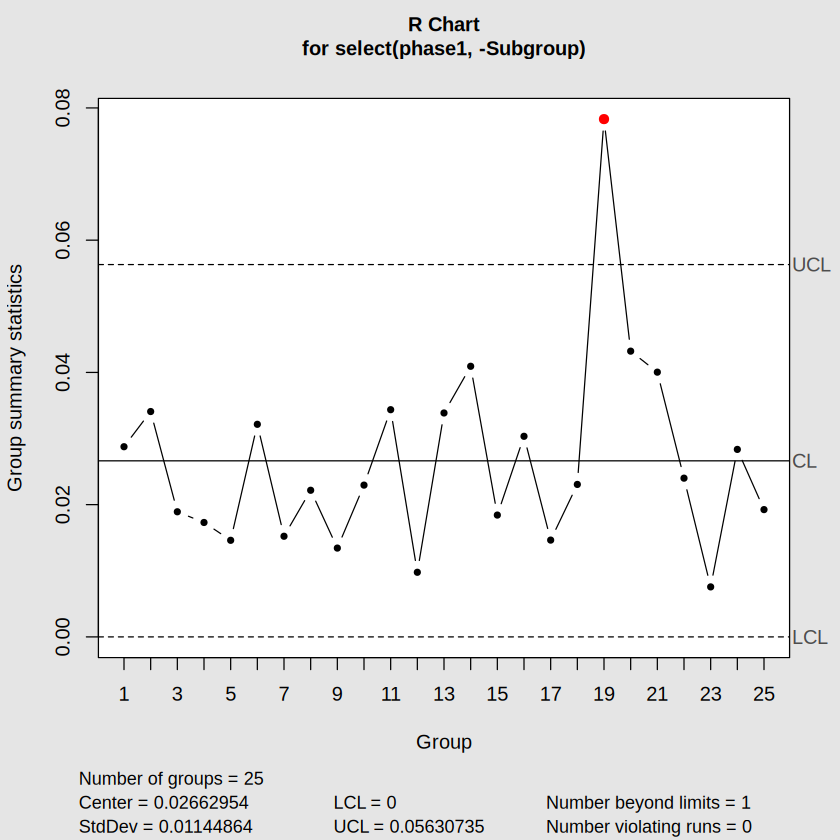

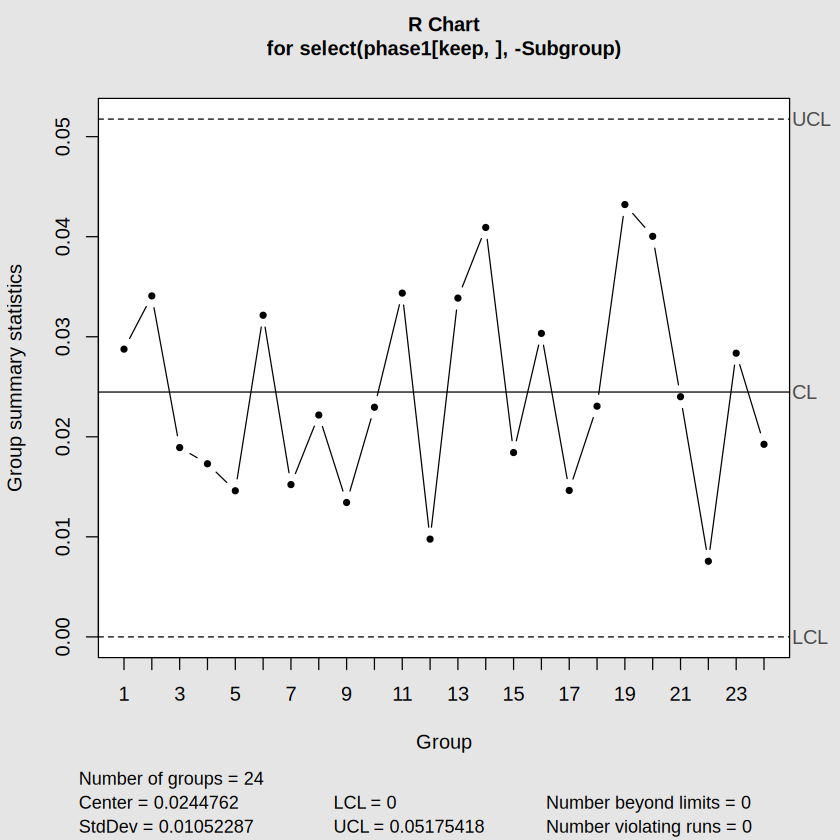

In [ ]:
## Save and plot phase 1 xbar chart ##

phase1_rchart <- qcc(phase1 |> select(-`Subgroup`),
                    type = "R", plot = TRUE)

keep <-setdiff(1:25, 19)

phase1_rchart_keep <- qcc(phase1[keep, ] |> select(-`Subgroup`),
                    type = "R", plot = TRUE)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.
### Answer: Week 12 is showing that it is out of control.  The $\bar{X}$ is over the UCL and is also more than 1.80.  When looking at the data you can see that almost the entire week was above 1.80 except for one that was extremely close.  It is possible that the measurement equipment was not properly calibrated during that week or there was change in the manufacturing process equipment.

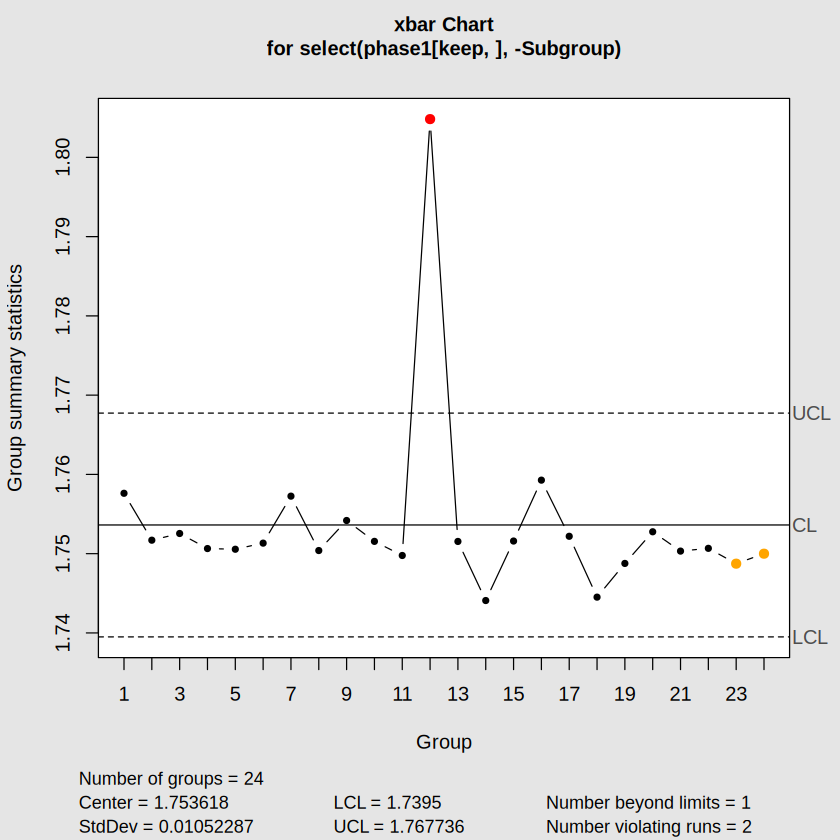

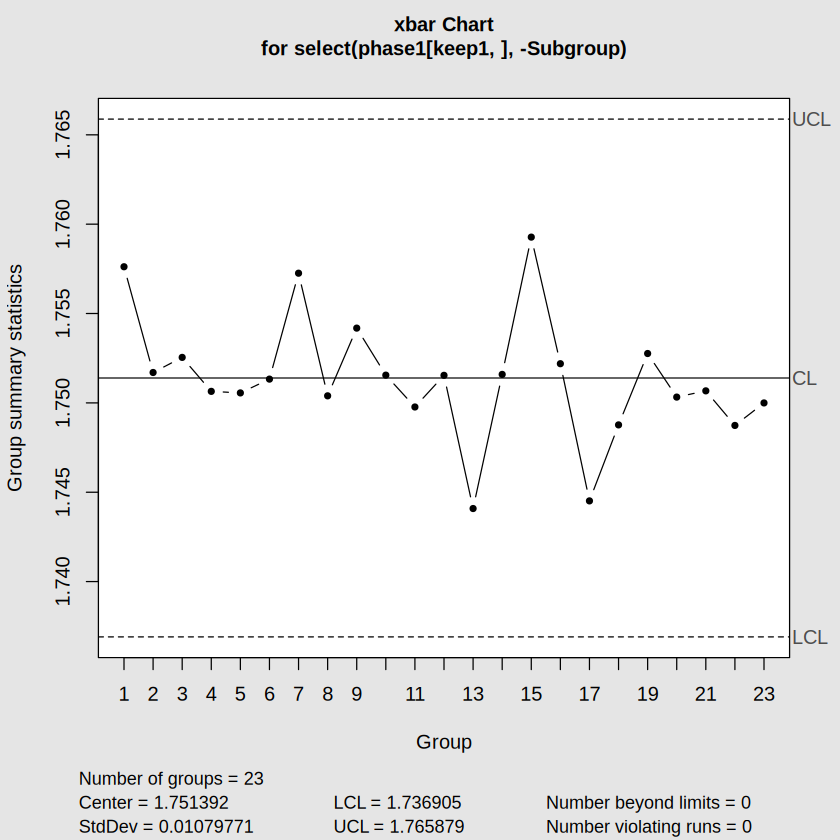

In [ ]:
phase1_xchart <- qcc(phase1[keep, ] |> select(-`Subgroup`),
                    type = "xbar", plot = TRUE)

keep1 <-setdiff(1:25, c(12, 19))

phase1_xchart_keep <- qcc(phase1[keep1, ] |> select(-`Subgroup`),
                    type = "xbar", plot = TRUE)

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

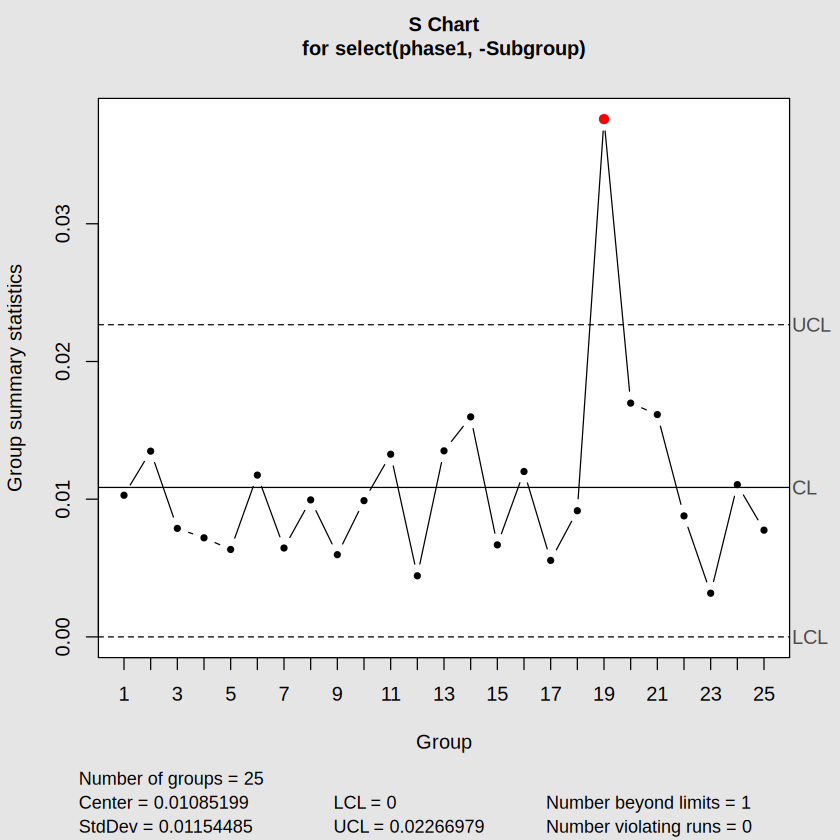

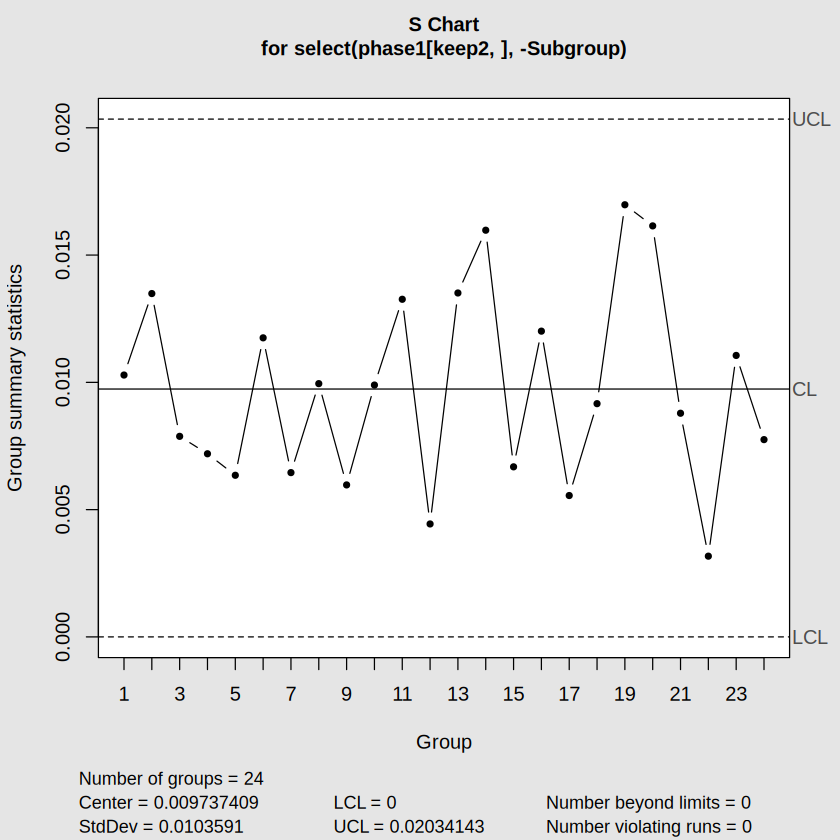

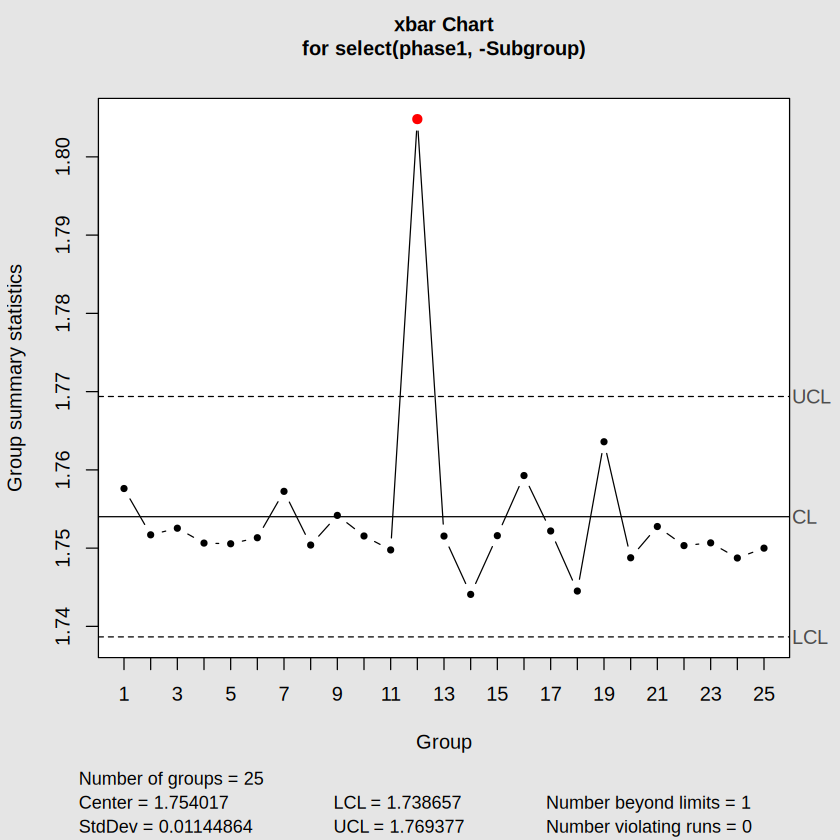

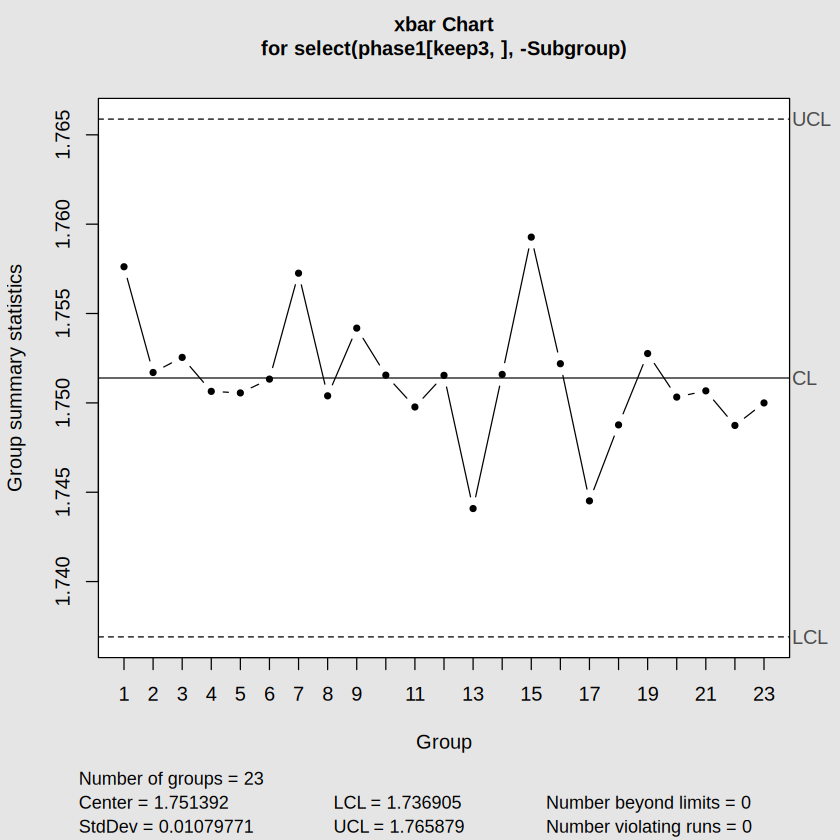

In [ ]:
#qcc(phase1, type = "S", labels = 1:25)                       # week 19 flagged again

phase1_schart <- qcc(phase1 |> select(-`Subgroup`),
                    type = "S", plot = TRUE)

keep2 <- setdiff(1:25, 19)

phase1_schart_keep <- qcc(phase1[keep2, ] |> select(-`Subgroup`),
                    type = "S", plot = TRUE)

phase1_xchart2 <- qcc(phase1 |> select(-`Subgroup`),
                    type = "xbar", plot = TRUE)

keep3 <- setdiff(1:25, c(12, 19))

phase1_xchart2_keep <- qcc(phase1[keep3, ] |> select(-`Subgroup`),
                    type = "xbar", plot = TRUE)


### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

### Answer:  The process is capable of meeting specifications and it is also well centered.  According the FNC approximately 3 out of 1 million spools would be out of specification.  The Cp is above 1 which means the process is capable.  The Cpk is close to the Cp so the process is close to being centered.  Also, the Cpm is close to Cp which agrees with the process being capable.

In [55]:
clean <- phase_1[keep3, ]
mu_final    <- mean(rowMeans(clean))
sigma_final <- mean(apply(clean, 1, sd)) / 0.9400
c(mu_final, sigma_final)


LSL <- 1.700
USL <- 1.800
target <- 1.750
FNC <- pnorm(LSL, mu_final, sigma_final) + (1 - pnorm(USL, mu_final, sigma_final))
Cp  <- (USL - LSL) / (6 * sigma_final)
Cpk <- min(USL - mu_final, mu_final - LSL) / (3 * sigma_final)
Cpm <- (USL - LSL) / (6 * sqrt(sigma_final^2 + (mu_final - target)^2))
round(c(FNC = FNC, Cp = Cp, Cpk = Cpk, Cpm = Cpm), 6)


[1] 1.75139206 0.01060412

FNC       Cp      Cpk      Cpm 
0.000003 1.571716 1.527958 1.558346

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.
### Answer: It is not advisable becasue those points are not part of the normal process.  Those points show that the process is out of control and would skew the data and therefore widening the control limits of the process.  That would mean for the future it would be more difficult to detect real shifts in the chart.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

### Answer: No, none of the subgroups plot outside the control limits.

List of 15
 $ call        : language qcc(data = select(phase1[keep3, ], -Subgroup), type = "xbar", newdata = select(phase2,      -Subgroup), plot = TRUE)
 $ type        : chr "xbar"
 $ data.name   : chr "select(phase1[keep3, ], -Subgroup)"
 $ data        : num [1:23, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics  : Named num [1:23] 1.76 1.75 1.75 1.75 1.75 ...
  ..- attr(*, "names")= chr [1:23] "1" "2" "3" "4" ...
 $ sizes       : int [1:23] 5 5 5 5 5 5 5 5 5 5 ...
 $ center      : num 1.75
 $ std.dev     : num 0.0108
 $ newstats    : Named num [1:20] 1.75 1.75 1.75 1.75 1.75 ...
  ..- attr(*, "names")= chr [1:20] "24" "25" "26" "27" ...
 $ newdata     : num [1:20, 1:5] 1.74 1.75 1.76 1.75 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ newsizes    : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ newdata.name: chr "select(phase2, -Subgroup)"
 $ nsigmas     : num 3
 $ limits      : num [1, 1:2] 1.74 1.77
  ..- attr(*, "dimnames")=List of 2
 $ violations  :Li

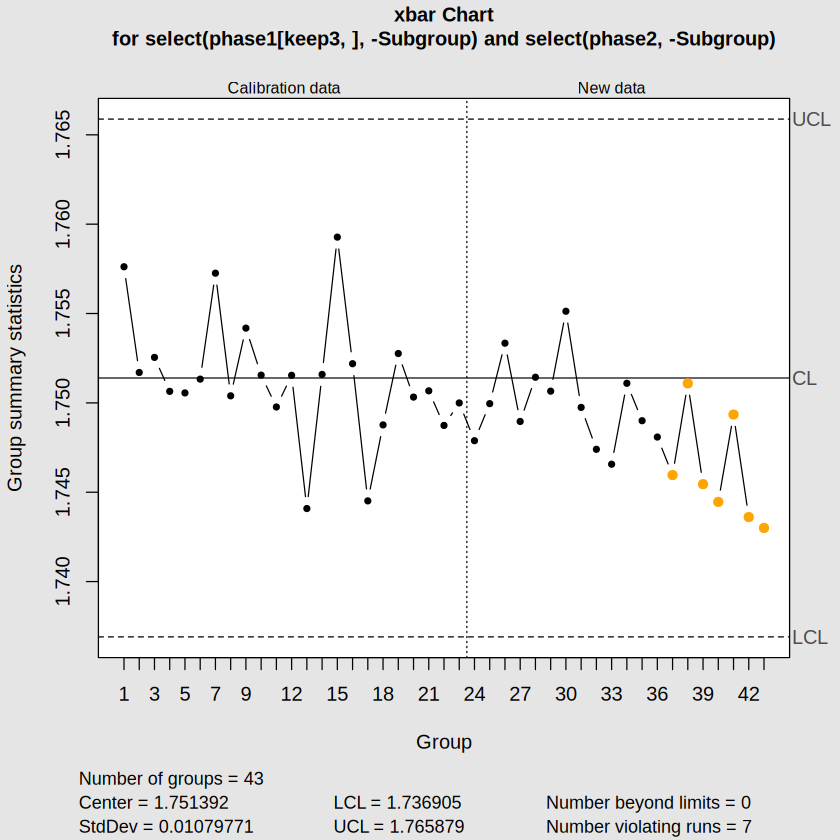

In [62]:
#phase2_xchart <- qcc(phase1[keep3, ] |> select(-`Subgroup`),
#                    type = "xbar", plot = TRUE, newdata = phase2)

qcc(phase1[keep3, ] |> select(-`Subgroup`),
                     type = "xbar", plot = TRUE, newdata = phase2 |> select(-`Subgroup`))

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?
### Answer: No, none of the subgroups plot outside the control limits.

List of 15
 $ call        : language qcc(data = select(phase1[keep3, ], -Subgroup), type = "S", newdata = select(phase2,      -Subgroup), plot = TRUE)
 $ type        : chr "S"
 $ data.name   : chr "select(phase1[keep3, ], -Subgroup)"
 $ data        : num [1:23, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics  : Named num [1:23] 0.01029 0.01349 0.00788 0.00719 0.00635 ...
  ..- attr(*, "names")= chr [1:23] "1" "2" "3" "4" ...
 $ sizes       : int [1:23] 5 5 5 5 5 5 5 5 5 5 ...
 $ center      : num 0.00997
 $ std.dev     : num 0.0106
 $ newstats    : Named num [1:20] 0.00989 0.00292 0.00445 0.00625 0.00177 ...
  ..- attr(*, "names")= chr [1:20] "24" "25" "26" "27" ...
 $ newdata     : num [1:20, 1:5] 1.74 1.75 1.76 1.75 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ newsizes    : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ newdata.name: chr "select(phase2, -Subgroup)"
 $ nsigmas     : num 3
 $ limits      : num [1, 1:2] 0 0.0208
  ..- attr(*, "dimnames")=Li

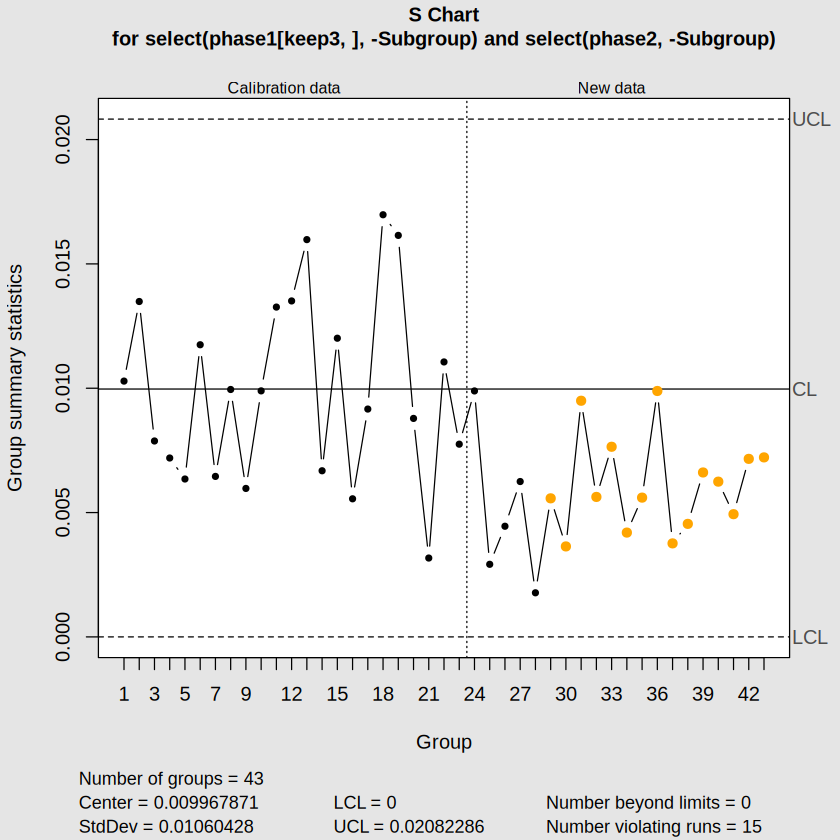

In [63]:
qcc(phase1[keep3, ] |> select(-`Subgroup`),
                     type = "S", plot = TRUE, newdata = phase2 |> select(-`Subgroup`))

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

### I do not think they need to completely overhaul line 3.  I believe that it is salvagable.  There were only two weeks of the 25 that were not in control during phase 1.  Then in the next 20 weeks there were not any subgroups out of control, although they were consistently lower than average.  I would suggest investigating weeks 12 and 19 as to what the caused the issue but I would not take the whole line down.  I would stay the course unless another issue arises later on in the future.